<a href="https://colab.research.google.com/github/marcheanin/hf_llm_course/blob/main/5_The-Datasets-Library/HF_LLM_Datasets_Library.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. The Datasets Library

## Not from hub datasets

Способы загруки датасета:

| Data format         | Loading script | Example                                              |
|---------------------|----------------|------------------------------------------------------|
| CSV & TSV           | csv            | `load_dataset("csv", data_files="my_file.csv")`     |
| Text files          | text           | `load_dataset("text", data_files="my_file.txt")`    |
| JSON & JSON Lines   | json           | `load_dataset("json", data_files="my_file.jsonl")`  |
| Pickled DataFrames  | pandas         | `load_dataset("pandas", data_files="my_dataframe.pkl")` |

Далее рассмотрим детально как загрузить внешний датасет и преобразовать его в HF Dataset.

Грузим, например, с гита:

In [ ]:
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-test.json.gz

--2026-05-11 08:05:32--  https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/crux82/squad-it/master/SQuAD_it-train.json.gz [following]
--2026-05-11 08:05:33--  https://raw.githubusercontent.com/crux82/squad-it/master/SQuAD_it-train.json.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7725286 (7.4M) [application/octet-stream]
Saving to: ‘SQuAD_it-train.json.gz’

SQuAD_it-train.json 100%[===================>]   7.37M  --.-KB/s    in 0.1s    

2026-05-11 08:05:33 (63.0 MB/s) - ‘SQuAD_it-train.json.gz’ saved [7725286/7725286]

--202

Распаковываем и смотрим что получилось

In [ ]:
!gzip -dkv SQuAD_it-*.json.gz

SQuAD_it-test.json.gz:	 87.5% -- created SQuAD_it-test.json
SQuAD_it-train.json.gz:	 82.3% -- created SQuAD_it-train.json


Теперь мы можем загрузить Dataset напрямую из json файла. Данные в json-файле доджны быть корректно разделены

In [ ]:
from datasets import load_dataset

squad_it_dataset = load_dataset("json", data_files="SQuAD_it-train.json", field="data")

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
squad_it_dataset

DatasetDict({
    train: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 442
    })
})

In [ ]:
squad_it_dataset["train"][0]

{'title': 'Terremoto del Sichuan del 2008',
 'paragraphs': [{'context': "Il terremoto del Sichuan del 2008 o il terremoto del Gran Sichuan, misurato a 8.0 Ms e 7.9 Mw, e si è verificato alle 02:28:01 PM China Standard Time all' epicentro (06:28:01 UTC) il 12 maggio nella provincia del Sichuan, ha ucciso 69.197 persone e lasciato 18.222 dispersi.",
   'qas': [{'answers': [{'answer_start': 29, 'text': '2008'}],
     'id': '56cdca7862d2951400fa6826',
     'question': 'In quale anno si è verificato il terremoto nel Sichuan?'},
    {'answers': [{'answer_start': 232, 'text': '69.197'}],
     'id': '56cdca7862d2951400fa6828',
     'question': 'Quante persone sono state uccise come risultato?'},
    {'answers': [{'answer_start': 29, 'text': '2008'}],
     'id': '56d4f9902ccc5a1400d833c0',
     'question': 'Quale anno ha avuto luogo il terremoto del Sichuan?'},
    {'answers': [{'answer_start': 78, 'text': '8.0 Ms e 7.9 Mw'}],
     'id': '56d4f9902ccc5a1400d833c1',
     'question': 'Che cosa ha

Теперь разрузим train и test части в соотвествующих словарь

In [ ]:
data_files = {"train": "SQuAD_it-train.json", "test": "SQuAD_it-test.json"}
squad_it_dataset = load_dataset("json", data_files=data_files, field="data")
squad_it_dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 442
    })
    test: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 48
    })
})

Теперь датасет готов к препроцессингу и всему, что мы делали для применения в дообучении.

Можно также сделать эти фукнкции одной командой, указав место скачивания

In [ ]:
url = "https://github.com/crux82/squad-it/raw/master/"
data_files = {
    "train": url + "SQuAD_it-train.json.gz",
    "test": url + "SQuAD_it-test.json.gz",
}
squad_it_dataset = load_dataset("json", data_files=data_files, field="data")

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
squad_it_dataset

DatasetDict({
    train: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 442
    })
    test: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 48
    })
})

## Time to Slice and Dice

Тут рассмотрим как преобрабатывать данные в датасетах для корректной передачи в модель. Многие из методов похожи на pandas преобразования

Возьмем небольшой даатсет для экспериментов

In [ ]:
!wget "https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip"
!unzip drugsCom_raw.zip

--2026-05-11 08:05:47--  https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘drugsCom_raw.zip’

drugsCom_raw.zip        [     <=>            ]  41.00M  39.7MB/s    in 1.0s    

2026-05-11 08:05:49 (39.7 MB/s) - ‘drugsCom_raw.zip’ saved [42989872]

Archive:  drugsCom_raw.zip
  inflating: drugsComTest_raw.tsv    
  inflating: drugsComTrain_raw.tsv   


TSV - как csv, только разделены табуляцией. Учтем это при загрузке

In [ ]:
from datasets import load_dataset

data_files = {"train": "drugsComTrain_raw.tsv", "test": "drugsComTest_raw.tsv"}
# \t is the tab character in Python
drug_dataset = load_dataset("csv", data_files=data_files, delimiter="\t")

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Хорошая практика перед предобработкой - посмотреть рандомную выборку из датасета, чтобы понять его содержимое

In [ ]:
drug_sample = drug_dataset["train"].shuffle(seed=42).select(range(1000))
# Peek at the first few examples
drug_sample[:3]

{'Unnamed: 0': [87571, 178045, 80482],
 'drugName': ['Naproxen', 'Duloxetine', 'Mobic'],
 'condition': ['Gout, Acute', 'ibromyalgia', 'Inflammatory Conditions'],
 'review': ['"like the previous person mention, I&#039;m a strong believer of aleve, it works faster for my gout than the prescription meds I take. No more going to the doctor for refills.....Aleve works!"',
  '"I have taken Cymbalta for about a year and a half for fibromyalgia pain. It is great\r\nas a pain reducer and an anti-depressant, however, the side effects outweighed \r\nany benefit I got from it. I had trouble with restlessness, being tired constantly,\r\ndizziness, dry mouth, numbness and tingling in my feet, and horrible sweating. I am\r\nbeing weaned off of it now. Went from 60 mg to 30mg and now to 15 mg. I will be\r\noff completely in about a week. The fibro pain is coming back, but I would rather deal with it than the side effects."',
  '"I have been taking Mobic for over a year with no side effects other than 

Проверим, совпадает ли число уникальных id с числом строк, чтобы удостовериться, что пользователи не повторяются

In [ ]:
for split in drug_dataset.keys():
    assert len(drug_dataset[split]) == len(drug_dataset[split].unique("Unnamed: 0"))

Переименуем первую колонку на что-то более интерпретируемое:

In [ ]:
drug_dataset = drug_dataset.rename_column(
    original_column_name="Unnamed: 0", new_column_name="patient_id"
)
drug_dataset

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 161297
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 53766
    })
})

Также, удобно определять функции для применения к колонкам датасета. Напишем функцию, которая применяет lowercase ко всему тексту

In [ ]:
def lowercase_condition(example):
    return {"condition": example["condition"].lower()}


drug_dataset.map(lowercase_condition)

Map:   0%|          | 0/161297 [00:00<?, ? examples/s]

AttributeError: 'NoneType' object has no attribute 'lower'

Не работает, потому что в датасете есть пропуски. Напишем такие же функции для фильтрации.

In [ ]:
def filter_nones(x):
    return x["condition"] is not None

In [ ]:
drug_dataset = drug_dataset.filter(lambda x: x["condition"] is not None)

Filter:   0%|          | 0/161297 [00:00<?, ? examples/s]

Filter:   0%|          | 0/53766 [00:00<?, ? examples/s]

In [ ]:
drug_dataset = drug_dataset.map(lowercase_condition)
# Check that lowercasing worked
drug_dataset["train"]["condition"][:3]

Map:   0%|          | 0/160398 [00:00<?, ? examples/s]

Map:   0%|          | 0/53471 [00:00<?, ? examples/s]

['left ventricular dysfunction', 'adhd', 'birth control']

### Creating new columns

Новые колонки часто нужны для кастомных признаков или друхи проверок.

In [ ]:
def compute_review_length(example):
    return {"review_length": len(example["review"].split())}

In [ ]:
drug_dataset = drug_dataset.map(compute_review_length)
# Inspect the first training example
drug_dataset["train"][0]

Map:   0%|          | 0/160398 [00:00<?, ? examples/s]

Map:   0%|          | 0/53471 [00:00<?, ? examples/s]

{'patient_id': 206461,
 'drugName': 'Valsartan',
 'condition': 'left ventricular dysfunction',
 'review': '"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"',
 'rating': 9.0,
 'date': 'May 20, 2012',
 'usefulCount': 27,
 'review_length': 17}

для этого датасета стоит оставить толбко отзывы длинее 30 слов, чтобы было репрезентативно для обучения.

In [ ]:
drug_dataset = drug_dataset.filter(lambda x: x["review_length"] > 30)
print(drug_dataset.num_rows)

Filter:   0%|          | 0/160398 [00:00<?, ? examples/s]

Filter:   0%|          | 0/53471 [00:00<?, ? examples/s]

{'train': 138514, 'test': 46108}


Текст отзывов в html, можем применить такую функци для примера, а потом и для всего датасета.

In [ ]:
import html

text = "I&#039;m a transformer called BERT"
html.unescape(text)

"I'm a transformer called BERT"

In [ ]:
drug_dataset = drug_dataset.map(lambda x: {"review": html.unescape(x["review"])})

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

## Dataset map()

В метод map() можно передать аргумент batched, что позволит применять написанную функцию сразу к батчу размером до 1000 примеров, что позволит сильно ускорить процесс.

In [ ]:
new_drug_dataset = drug_dataset.map(
    lambda x: {"review": [html.unescape(o) for o in x["review"]]}, batched=True
)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

Особенно это полезно при применении токенайзеров, весьма актуальных для датасетов.
| Options         | Fast tokenizer | Slow tokenizer |
|-----------------|----------------|----------------|
| batched=True    | 10.8s          | 4min41s        |
| batched=False   | 59.2s          | 5min3s         |

Возвращаясь к библиотеке `AutoTokenizer` вспомним, что она написана на Rust для более удобного распарллеливания процессов. Этот параметр можно указать и прямо выиграть за счет доп ресурсов.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


def tokenize_function(examples):
    return tokenizer(examples["review"], truncation=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
slow_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", use_fast=False)


def slow_tokenize_function(examples):
    return slow_tokenizer(examples["review"], truncation=True)


tokenized_dataset = drug_dataset.map(slow_tokenize_function, batched=True, num_proc=8)

Map (num_proc=8):   0%|          | 0/138514 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/46108 [00:00<?, ? examples/s]

Посмотрим на сравнительную таблицу скорости

| Options                     | Fast tokenizer | Slow tokenizer |
|-----------------------------|----------------|----------------|
| batched=True                | 10.8s          | 4min41s        |
| batched=False               | 59.2s          | 5min3s         |
| batched=True, num_proc=8    | 6.52s          | 41.3s          |
| batched=False, num_proc=8   | 9.49s          | 45.2s          |

Теперь важны момент

Обычно `Dataset.map()` применяет функцию к каждому примеру и возвращает такое же кол-во примеров. Но с параметром `batched=True` и использованием `return_overflowing_tokens=True` можем увеличить кол-во примеров.

Это нужно, чтобы не терять дополнительные токены, которые не помещаются в окно токенайзера (напрмиер). То есть при таком подходе текст режется на чанки, и они возвращаются массивом.

При этом эти чанки уходят в доп строки датасета, вот пример:

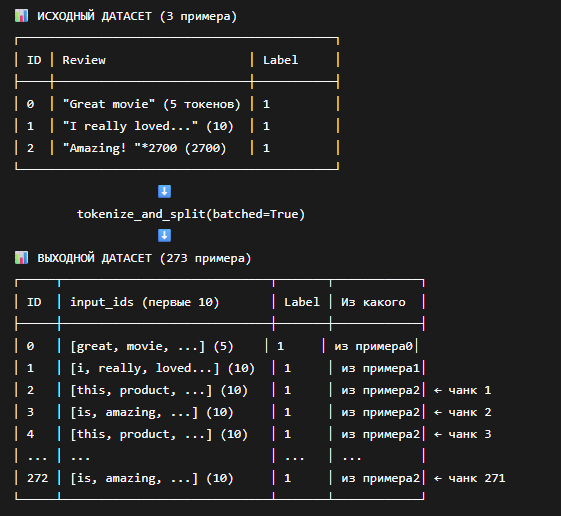

In [ ]:
def tokenize_and_split(examples):
    result = tokenizer(
        examples["review"],
        truncation=True,
        max_length=128,
        return_overflowing_tokens=True,
    )
    # Extract mapping between new and old indices
    sample_map = result.pop("overflow_to_sample_mapping")
    for key, values in examples.items():
        result[key] = [values[i] for i in sample_map]
    return result

ПО сути нам нужно вернуть потерянные метки, мы это делаем в цикле после применения токенайзера

В этом случае кол-во строк уже не увеличится, а каждая фича будет представлена словарем из кодированных батчей.

In [ ]:
tokenized_dataset = drug_dataset.map(tokenize_and_split, batched=True)
tokenized_dataset

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 206772
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 68876
    })
})

In [ ]:
single_example = drug_dataset["train"][0]
batched_single_example = {k: [v] for k, v in single_example.items()}
result = tokenize_and_split(batched_single_example)
[len(inp) for inp in result["input_ids"]]

[128, 49]

In [ ]:
tokenized_dataset = drug_dataset.map(tokenize_and_split, batched=True)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

In [ ]:
len(tokenized_dataset["train"]), len(drug_dataset["train"])

(206772, 138514)

In [ ]:
tokenized_dataset = drug_dataset.map(tokenize_and_split, batched=True)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 206772
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 68876
    })
})

Можно преобразовать датасет в вид pandas для совместимости

In [ ]:
drug_dataset.set_format("pandas")

Теперь получаем pandas.DataFrame вместо словаря

In [ ]:
drug_dataset["train"][:3]

,patient_id,drugName,condition,review,rating,date,usefulCount,review_length
0,95260,Guanfacine,adhd,"""My son is halfway through his fourth week of ...",8.0,"April 27, 2010",192,141
1,92703,Lybrel,birth control,"""I used to take another oral contraceptive, wh...",5.0,"December 14, 2009",17,134
2,138000,Ortho Evra,birth control,"""This is my first time using any form of birth...",8.0,"November 3, 2015",10,89


Теперь чтобы создать тренеровочный set, просто выберем все первые элементы словаря

In [ ]:
train_df = drug_dataset["train"][:]

Теперь можем, например, посчитать частоту всречаемости классов через стандартную статистику pandas

In [ ]:
frequencies = (
    train_df["condition"]
    .value_counts()
    .to_frame()
    .reset_index()
    .rename(columns={"index": "condition", "count": "frequency"})
)
frequencies.head()

,condition,frequency
0,birth control,27655
1,depression,8023
2,acne,5209
3,anxiety,4991
4,pain,4744


Также, можно создать Dataset из pandas объекта

In [ ]:
from datasets import Dataset

freq_dataset = Dataset.from_pandas(frequencies)
freq_dataset

Dataset({
    features: ['condition', 'frequency'],
    num_rows: 819
})

In [ ]:
drug_dataset.reset_format() # сбрасываем формат вывода с Pandas в Arrow

Теперь создадим validation set.

Для этого используем ооочень полезный метод train_test_split.

In [ ]:
drug_dataset_clean = drug_dataset["train"].train_test_split(train_size=0.8, seed=42)
# Rename the default "test" split to "validation"
drug_dataset_clean["validation"] = drug_dataset_clean.pop("test")
# Add the "test" set to our `DatasetDict`
drug_dataset_clean["test"] = drug_dataset["test"]
drug_dataset_clean

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 110811
    })
    validation: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 27703
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 46108
    })
})

## Работа с большими данными

In [ ]:
!pip install zstandard

Тут посмотрим как работать с большими датасетами в режиме стриминга данных чтобы не хранить их одновременно в памяти

In [ ]:
from datasets import load_dataset

# This takes a few minutes to run, so go grab a tea or coffee while you wait :)
data_files = "https://the-eye.eu/public/AI/pile_preliminary_components/PUBMED_title_abstracts_2019_baseline.jsonl.zst"
pubmed_dataset = load_dataset("json", data_files=data_files, split="train")
pubmed_dataset

Датасет сожержит набор текстов и используется для обучения LLM.

Dataset хранит данные в memory-mapped файле, который позволяет сократить использование оперативной памяти в 4-5 раз от размера датасета.

Также, можно воспользоваться стримингом датасета. Он возвращает объект IterableDataset, который можно использовать для итеграции по датасету.

In [ ]:
pubmed_dataset_streamed = load_dataset(
    "json", data_files=data_files, split="train", streaming=True
)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tokenized_dataset = pubmed_dataset_streamed.map(lambda x: tokenizer(x["text"]))
next(iter(tokenized_dataset))

У этого датасета также есть map() функция с аналогичным механизмом работы.

## Semantic search with faiss

Можно рассматривать эмбеддинги как элементы семантического пространства и рассматривать поиск в нем. Возьмем тестовый датасет для этой задачи

In [ ]:
from datasets import load_dataset

issues_dataset = load_dataset("lewtun/github-issues", split="train")
issues_dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['url', 'repository_url', 'labels_url', 'comments_url', 'events_url', 'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels', 'state', 'locked', 'assignee', 'assignees', 'milestone', 'comments', 'created_at', 'updated_at', 'closed_at', 'author_association', 'active_lock_reason', 'pull_request', 'body', 'timeline_url', 'performed_via_github_app', 'is_pull_request'],
    num_rows: 3019
})

Так как мы указали, что скачиваем train, вернулся Dataset, а не DatasetDict.

Теперь отфильтруем pull requests

In [ ]:
issues_dataset = issues_dataset.filter(
    lambda x: (x["is_pull_request"] == False and len(x["comments"]) > 0)
)
issues_dataset

Dataset({
    features: ['url', 'repository_url', 'labels_url', 'comments_url', 'events_url', 'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels', 'state', 'locked', 'assignee', 'assignees', 'milestone', 'comments', 'created_at', 'updated_at', 'closed_at', 'author_association', 'active_lock_reason', 'pull_request', 'body', 'timeline_url', 'performed_via_github_app', 'is_pull_request'],
    num_rows: 808
})

Видим в датасете много колонок, которые не понадобятся для построения поискового движка. Используем метод для их удаления

In [ ]:
columns = issues_dataset.column_names
columns_to_keep = ["title", "body", "html_url", "comments"]
columns_to_remove = set(columns_to_keep).symmetric_difference(columns)
issues_dataset = issues_dataset.remove_columns(columns_to_remove)
issues_dataset

Dataset({
    features: ['html_url', 'title', 'comments', 'body'],
    num_rows: 808
})

Чтобы построить эмбеддинг, объединим информацию из трех колонок

In [ ]:
issues_dataset.set_format("pandas")
df = issues_dataset[:]

In [ ]:
df["comments"][0].tolist()

['Cool, I think we can do both :)',
 '@lhoestq now the 2 are implemented.\r\n\r\nPlease note that for the the second protection, finally I have chosen to protect the master branch only from **merge commits** (see update comment above), so no need to disable/re-enable the protection on each release (direct commits, different from merge commits, can be pushed to the remote master branch; and eventually reverted without messing up the repo history).']

In [ ]:
comments_df = df.explode("comments", ignore_index=True)
comments_df.head(4)

,html_url,title,comments,body
0,https://github.com/huggingface/datasets/issues...,Protect master branch,"Cool, I think we can do both :)",After accidental merge commit (91c55355b634d0d...
1,https://github.com/huggingface/datasets/issues...,Protect master branch,@lhoestq now the 2 are implemented.\r\n\r\nPle...,After accidental merge commit (91c55355b634d0d...
2,https://github.com/huggingface/datasets/issues...,Backwards compatibility broken for cached data...,Hi ! I guess the caching mechanism should have...,## Describe the bug\r\nAfter upgrading to data...
3,https://github.com/huggingface/datasets/issues...,Backwards compatibility broken for cached data...,"If it's easy enough to implement, then yes ple...",## Describe the bug\r\nAfter upgrading to data...


После обработки через Pandas, возвращаем в формат датасета

In [ ]:
from datasets import Dataset

comments_dataset = Dataset.from_pandas(comments_df)
comments_dataset

Dataset({
    features: ['html_url', 'title', 'comments', 'body'],
    num_rows: 2964
})

Теперь создадим колонку, отражающую кол-во слов в комментарии

In [ ]:
comments_dataset = comments_dataset.map(
    lambda x: {"comment_length": len(x["comments"].split())}
)

Map:   0%|          | 0/2964 [00:00<?, ? examples/s]

Теперь наконец объединим фича-колонки в единый текст для последующего эмбеддинга

In [ ]:
def concatenate_text(examples):
    return {
        "text": examples["title"]
        + " \n "
        + examples["body"]
        + " \n "
        + examples["comments"]
    }


comments_dataset = comments_dataset.map(concatenate_text)

Map:   0%|          | 0/2964 [00:00<?, ? examples/s]

Для эмбеддигов возмем модель для этого, также возьмем cuda для ускорения.

In [ ]:
from transformers import AutoTokenizer, AutoModel

model_ckpt = "sentence-transformers/multi-qa-mpnet-base-dot-v1"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModel.from_pretrained(model_ckpt)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-dot-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import torch

device = torch.device("cuda")
model.to(device)

MPNetModel(
  (embeddings): MPNetEmbeddings(
    (word_embeddings): Embedding(30527, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): MPNetEncoder(
    (layer): ModuleList(
      (0-11): 12 x MPNetLayer(
        (attention): MPNetAttention(
          (attn): MPNetSelfAttention(
            (q): Linear(in_features=768, out_features=768, bias=True)
            (k): Linear(in_features=768, out_features=768, bias=True)
            (v): Linear(in_features=768, out_features=768, bias=True)
            (o): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (intermediate): MPNetIntermediate(
          (dense): Linear(in_

In [ ]:
def get_embeddings(text_list):
    encoded_input = tokenizer(
        text_list, padding=True, truncation=True, return_tensors="pt"
    )
    encoded_input = {k: v.to(device) for k, v in encoded_input.items()}
    model_output = model(**encoded_input)
    return cls_pooling(model_output)

In [ ]:
def cls_pooling(model_output):
    return model_output.last_hidden_state[:, 0]

In [ ]:
embedding = get_embeddings(comments_dataset["text"][0])
embedding.shape

torch.Size([1, 768])

На одном примере всё работает, теперь посчитаем эмбеддинги всего датасета

Выше мы берем первый CLS токен, так как он учит эмбеддинг всего предложения

In [ ]:
embeddings_dataset = comments_dataset.map(
    lambda x: {"embeddings": get_embeddings(x["text"]).detach().cpu().numpy()[0]}
)

Map:   0%|          | 0/2964 [00:00<?, ? examples/s]

In [ ]:
embedding = get_embeddings(comments_dataset["text"][0])
embedding.shape

torch.Size([1, 768])

Теперь перейдем к использованию FAISS. С его помощью будет находить ближайших соседей к нашему запросу, такми образом осуществляя поиск.

In [ ]:
embeddings_dataset.add_faiss_index(column="embeddings")

  0%|          | 0/3 [00:00<?, ?it/s]

Dataset({
    features: ['html_url', 'title', 'comments', 'body', 'comment_length', 'text', 'embeddings'],
    num_rows: 2964
})

In [ ]:
import faiss
embeddings_dataset.add_faiss_index(column="embeddings")

  0%|          | 0/3 [00:00<?, ?it/s]

Dataset({
    features: ['html_url', 'title', 'comments', 'body', 'comment_length', 'text', 'embeddings'],
    num_rows: 2964
})

In [ ]:
question = "How can I load a dataset offline?"
question_embedding = get_embeddings([question]).cpu().detach().numpy()
question_embedding.shape

(1, 768)

In [ ]:
scores, samples = embeddings_dataset.get_nearest_examples(
    "embeddings", question_embedding, k=5
)

In [ ]:
import pandas as pd

samples_df = pd.DataFrame.from_dict(samples)
samples_df["scores"] = scores
samples_df.sort_values("scores", ascending=False, inplace=True)

In [ ]:
for _, row in samples_df.iterrows():
    print(f"COMMENT: {row.comments}")
    print(f"SCORE: {row.scores}")
    print(f"TITLE: {row.title}")
    print(f"URL: {row.html_url}")
    print("=" * 50)
    print()

COMMENT: Requiring online connection is a deal breaker in some cases unfortunately so it'd be great if offline mode is added similar to how `transformers` loads models offline fine.

@mandubian's second bullet point suggests that there's a workaround allowing you to use your offline (custom?) dataset with `datasets`. Could you please elaborate on how that should look like?
SCORE: 25.505016326904297
TITLE: Discussion using datasets in offline mode
URL: https://github.com/huggingface/datasets/issues/824

COMMENT: The local dataset builders (csv, text , json and pandas) are now part of the `datasets` package since #1726 :)
You can now use them offline
```python
datasets = load_dataset('text', data_files=data_files)
```

We'll do a new release soon
SCORE: 24.555538177490234
TITLE: Discussion using datasets in offline mode
URL: https://github.com/huggingface/datasets/issues/824

COMMENT: I opened a PR that allows to reload modules that have already been loaded once even if there's no intern